In [1]:
from numpy import argmax
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
y_pred = [ 0.66, 0.52, 0.77]
Y_test = [0.6, 0.5,  0.7]

r2 = r2_score(Y_test, y_pred)
print('r2 ',r2)

r2  0.554999999999999


In [3]:
y_pred = [0.52, 0.66, 0.77]
Y_test = [0.5, 0.6, 0.7]

r2 = r2_score(Y_test, y_pred)
print('r2 ',r2)

r2  0.554999999999999


In [4]:
y_pred = [0.52, 0.66, 0.77]
Y_test = [0.5, 0.6, 0.7]

r2 = r2_score(y_pred, Y_test)
print('r2 ',r2)

r2  0.7165605095541396


In [5]:
import pandas as pd

In [6]:
import numpy as np

df = pd.read_csv("All_external_test_Sets.csv")
df

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN


In [7]:
#df = df[df["source"]!="Lombardo"].reset_index(drop=True)
#df

In [8]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import inchi
from rdkit.Chem.MolStandardize import rdMolStandardize
import pickle
from mordred import Calculator, descriptors
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from sklearn.feature_selection import VarianceThreshold
from itertools import compress


from dimorphite_dl.dimorphite_dl import DimorphiteDL
from rdkit.Chem import AddHs
from rdkit.Chem.MolStandardize import rdMolStandardize

def standardize(smiles):
    # follows the steps in
    # https://github.com/greglandrum/RSC_OpenScience_Standardization_202104/blob/main/MolStandardize%20pieces.ipynb
    # as described **excellently** (by Greg) in
    # https://www.youtube.com/watch?v=eWTApNX8dJQ
    try: 
        mol = Chem.MolFromSmiles(smiles)
        #print(smiles)
        
        # removeHs, disconnect metal atoms, normalize the molecule, reionize the molecule
        clean_mol = rdMolStandardize.Cleanup(mol) 
        #print(Chem.MolToSmiles(clean_mol))
        
        # if many fragments, get the "parent" (the actual mol we are interested in) 
        parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

        # try to neutralize molecule
        uncharger = rdMolStandardize.Uncharger() # annoying, but necessary as no convenience method exists
        uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

        #print(uncharged_parent_clean_mol)
        
        # use pH 7.4 https://git.durrantlab.pitt.edu/jdurrant/dimorphite_dl/
        dimorphite = DimorphiteDL(min_ph=7.4, max_ph=7.4, pka_precision=0)
        protonated_smiles = dimorphite.protonate(Chem.MolToSmiles(uncharged_parent_clean_mol))

        #print("protonated_smiles")
        
        if len(protonated_smiles) > 0:
                protonated_smile = protonated_smiles[0]

        protonated_mol = Chem.MolFromSmiles(protonated_smile)
        #protonated_mol= AddHs(protonated_mol)
        #protonated_smile = Chem.MolToSmiles(protonated_mol)


        # attempt is made at reionization at this step
        # at 7.4 pH

        te = rdMolStandardize.TautomerEnumerator() # idem
        taut_uncharged_parent_clean_mol = te.Canonicalize(protonated_mol)
     
        return  Chem.MolToSmiles(taut_uncharged_parent_clean_mol)
    
    except: 
        
        return "Cannot_do"

    
def calcdesc(data):
    # create descriptor calculator with all descriptors
    calc = Calculator(descriptors, ignore_3D=True)

    #print(len(calc.descriptors))
    Ser_Mol = data['smiles_r'].apply(Chem.MolFromSmiles)
    Mordred_table=  calc.pandas(Ser_Mol)
    Mordred_table = Mordred_table.astype('float')
    Mordred_table['smiles_r'] = data['smiles_r']
    
    Morgan_fingerprint= Ser_Mol.apply(GetMorganFingerprintAsBitVect, args=(2, 2048))
    Morganfingerprint_array  = np.stack(Morgan_fingerprint)

    Morgan_collection  = []
    for x in np.arange(Morganfingerprint_array.shape[1]): #np.arange plus rapide que range
        x = "Mfp"+str(x)
        Morgan_collection.append(x)

    Morganfingerprint_table  = pd.DataFrame(Morganfingerprint_array , columns=Morgan_collection )
    Morganfingerprint_table['smiles_r'] = data['smiles_r']
    
    data_mfp = pd.merge(data, Morganfingerprint_table)
    data_mfp_Mordred = pd.merge(data_mfp, Mordred_table)
    
    return(data_mfp_Mordred)
    

def predict_individual_animal(data, endpoint, animal):#predict animal data
    
    #Read columns needed for rat data
    file = open(f"../features_mfp_mordred_columns_{animal}_model.txt", "r")
    file_lines = file.read()
    features = file_lines.split("\n")
    features = features[:-1]

    loaded_rf = pickle.load(open(f"../log_{endpoint}_model_FINAL.sav", 'rb'))

    X = data[features]
    y_pred =  loaded_rf.predict(X)   

    return(y_pred)

def predict_animal(data):
    
    endpoints = {"dog_VDss_L_kg","dog_CL_mL_min_kg","dog_fup"}

    for endpoint in endpoints:
        preds = predict_individual_animal(data, endpoint, "dog") 
        data[endpoint] = preds

    endpoints = {"monkey_VDss_L_kg","monkey_CL_mL_min_kg","monkey_fup"}

    for endpoint in endpoints:
        preds = predict_individual_animal(data, endpoint, "monkey") 
        data[endpoint] = preds
    
    endpoints = {"rat_VDss_L_kg","rat_CL_mL_min_kg","rat_fup"}

    for endpoint in endpoints:
        preds = predict_individual_animal(data, endpoint, "rat") 
        data[endpoint] = preds
    
    return(data)



def predict_VDss(data, features):#
    

    loaded_rf = pickle.load(open("../log_human_VDss_L_kg_withanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_CL(data, features):

    loaded_rf = pickle.load(open("../log_human_CL_mL_min_kg_withanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_fup(data, features):
    
    loaded_rf = pickle.load(open("../log_human_fup_withanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_MRT(data, features):
    
    

    loaded_rf = pickle.load(open("../log_human_mrt_withanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_thalf(data, features):
    
    loaded_rf = pickle.load(open("../log_human_thalf_withanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)  
    return(y_preds)

In [9]:
from pandarallel import pandarallel
pandarallel.initialize()

df["smiles_r"] = df["smiles_r"].parallel_apply(standardize)

INFO: Pandarallel will run on 56 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [10]:
def count(pred, true, min, max, endpoint):

    if(endpoint == "human_fup"):
        lst = [abs(a/b) for a, b in zip(pred, true)]
        #print(lst)

        newlist = [x for x in lst if min <= x <= max]
        #print(newlist)

        return (len(newlist)/len(lst)) *100
    
    else:
        lst = [abs(10**a/10**b) for a, b in zip(pred, true)]
        #print(lst)

        newlist = [x for x in lst if min <= x <= max]
        #print(newlist)

        return (len(newlist)/len(lst)) *100
    
    return

def calc_gmfe(pred, true, endpoint):
    
    if(endpoint == "human_fup"):
        
        lst = [abs(np.log10(a/b)) for a, b in zip(pred, true)]
        mean_abs= np.mean(lst)
        return (10**mean_abs)
    
    else: 
        lst = [abs(np.log10(10**a/10**b)) for a, b in zip(pred, true)]
        mean_abs= np.mean(lst)
        
        return (10** mean_abs)
    
    return
                         
def median_fold_change_error(pred, true, endpoint):
                         
    if (endpoint == "human_fup"):
        lst = [abs(np.log10(a/b)) for a, b in zip(pred, true)]
        median_abs= np.median(lst) 
        return (np.e**median_abs)
    
    else:
        lst = [abs(np.log10(10**a/10**b)) for a, b in zip(pred, true)]
        median_abs= np.median(lst) 
        return (np.e**median_abs)
    
    return
                          
def calc_bias(pred, true, endpoint):
                          
    if (endpoint == "human_fup"):
        lst = [(a - b) for a, b in zip(pred, true)]                 
        bias= np.median(lst)
        return bias
    
    else:
        lst = [(10**a - 10**b) for a, b in zip(pred, true)]                 
        bias= np.median(lst)
        return bias
    
    return

In [11]:
df

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN


In [12]:
animal_columns = ["dog_VDss_L_kg","dog_CL_mL_min_kg","dog_fup","monkey_VDss_L_kg","monkey_CL_mL_min_kg","monkey_fup", "rat_VDss_L_kg","rat_CL_mL_min_kg","rat_fup"]

#read from file features
file = open("../features_mfp_mordred_columns_human.txt", "r")
file_lines = file.read()
features_mfp_mordred_columns = file_lines.split("\n")
features_mfp_mordred_columns = features_mfp_mordred_columns[:-1]

In [13]:
features_mfp_mordred_columns

['nAcid',
 'nBase',
 'SpDiam_A',
 'VE1_A',
 'nBridgehead',
 'nS',
 'nP',
 'nF',
 'nX',
 'AATS0d',
 'AATS2d',
 'AATS3d',
 'AATS1s',
 'AATS1are',
 'AATS2are',
 'AATS3are',
 'AATS0p',
 'ATSC0c',
 'ATSC1c',
 'ATSC2c',
 'ATSC3c',
 'ATSC4c',
 'ATSC5c',
 'ATSC6c',
 'ATSC7c',
 'ATSC8c',
 'ATSC1se',
 'ATSC2se',
 'ATSC1pe',
 'ATSC3pe',
 'ATSC4pe',
 'ATSC5pe',
 'ATSC7pe',
 'ATSC8pe',
 'ATSC1p',
 'AATSC0dv',
 'AATSC1dv',
 'AATSC2dv',
 'AATSC3dv',
 'AATSC0s',
 'AATSC1s',
 'AATSC2s',
 'AATSC3s',
 'AATSC1v',
 'AATSC0i',
 'AATSC1i',
 'AATSC2i',
 'GATS1c',
 'GATS2c',
 'GATS2d',
 'GATS2se',
 'GATS1p',
 'GATS1i',
 'BCUTdv-1h',
 'BCUTdv-1l',
 'BCUTd-1h',
 'BCUTs-1h',
 'BCUTs-1l',
 'BCUTm-1l',
 'BCUTi-1l',
 'BalabanJ',
 'SM1_Dzm',
 'SM1_Dzi',
 'nBondsD',
 'nBondsT',
 'C2SP1',
 'C1SP2',
 'C3SP3',
 'C4SP3',
 'FCSP3',
 'Xch-6d',
 'Xch-7d',
 'Xch-6dv',
 'Xc-3d',
 'Xc-5d',
 'Xc-3dv',
 'Xc-5dv',
 'Xp-7dv',
 'NdsCH',
 'NdssC',
 'NaaaC',
 'NssssC',
 'NsNH3',
 'NssNH2',
 'NaaNH',
 'NsssNH',
 'NaaN',
 'NsssN',
 'NdO

In [14]:
data_mfp_Mordred = calcdesc(df)
data_mfp_Mordred

  1%|▍                                          | 3/315 [00:01<03:05,  1.68it/s]

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 42%|█████████████████                        | 131/315 [00:02<00:02, 84.80it/s]

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 93%|██████████████████████████████████████   | 292/315 [00:04<00:00, 96.08it/s]

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|█████████████████████████████████████████| 315/315 [00:05<00:00, 59.48it/s]


,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf,Mfp0,Mfp1,Mfp2,Mfp3,Mfp4,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN,0,0,0,0,0,...,9.949751,63.023277,301.097093,8.137759,828.0,37.0,110.0,130.0,6.527778,4.694444
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7,0,0,0,0,0,...,10.236346,84.096047,473.254717,6.959628,3973.0,51.0,180.0,206.0,7.638889,7.805556
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0,0,1,0,0,0,...,11.211996,126.438462,1220.892303,5.984766,38625.0,151.0,416.0,481.0,43.500000,19.416667
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN,0,0,0,0,0,...,10.930622,81.595235,339.183444,6.783669,1189.0,59.0,160.0,211.0,6.875000,5.034722
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN,0,0,0,0,0,...,10.596660,71.984835,296.177630,6.438644,892.0,47.0,132.0,168.0,7.902778,4.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN,0,0,0,0,0,...,9.570459,59.431680,356.246378,6.142179,2557.0,30.0,118.0,127.0,7.444444,6.111111
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN,0,0,0,0,0,...,10.752719,60.334421,327.219829,6.173959,1145.0,50.0,144.0,183.0,6.291667,4.993056
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN,0,0,0,0,0,...,10.962024,77.785047,357.194008,6.739510,1356.0,60.0,164.0,215.0,7.125000,5.284722
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN,0,0,0,0,0,...,9.161465,53.745115,134.023958,11.168663,105.0,12.0,52.0,61.0,2.833333,2.222222


In [15]:
data_mfp_Mordred_animal = predict_animal(data_mfp_Mordred)

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.w

In [16]:
data_for_pred = data_mfp_Mordred_animal

#data_for_pred = data_for_pred.dropna(subset=["Clearance_(CL)"]).reset_index(drop=True)
#data_for_pred = data_for_pred.dropna(subset=["Volume_of_distribution_(VDss)"]).reset_index(drop=True)
data_for_pred 

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf,Mfp0,Mfp1,Mfp2,Mfp3,Mfp4,...,mZagreb2,dog_fup,dog_VDss_L_kg,dog_CL_mL_min_kg,monkey_fup,monkey_VDss_L_kg,monkey_CL_mL_min_kg,rat_CL_mL_min_kg,rat_VDss_L_kg,rat_fup
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN,0,0,0,0,0,...,4.694444,0.245388,0.448056,1.369745,0.270671,0.246650,1.138341,1.173434,0.227824,0.146407
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7,0,0,0,0,0,...,7.805556,0.198911,0.538641,1.337214,0.258564,0.342934,1.275966,1.661005,0.746565,0.232020
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0,0,1,0,0,0,...,19.416667,0.372705,-0.059657,0.918575,0.519590,0.039749,1.058254,1.113399,0.345530,0.461444
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN,0,0,0,0,0,...,5.034722,0.508004,0.764006,1.709217,0.447238,0.655424,1.584808,1.847394,0.881248,0.563618
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN,0,0,0,0,0,...,4.500000,0.334212,0.504148,1.233055,0.270524,0.428187,1.385239,1.494545,0.356129,0.274858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN,0,0,0,0,0,...,6.111111,0.366747,0.394918,1.158695,0.339345,0.216627,1.131856,1.561839,0.480405,0.385197
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN,0,0,0,0,0,...,4.993056,0.378205,0.939043,1.666884,0.306050,0.620369,1.496695,1.874632,0.717780,0.339850
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN,0,0,0,0,0,...,5.284722,0.526357,0.799991,1.585806,0.514733,0.680856,1.560330,1.900962,1.008218,0.557291
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN,0,0,0,0,0,...,2.222222,0.717522,-0.568069,0.151345,0.538390,0.027820,1.024017,1.105623,-0.273104,0.553060


In [17]:
data_for_pred[["smiles_r" ,"dog_CL_mL_min_kg",
               "dog_fup","dog_VDss_L_kg","monkey_CL_mL_min_kg","monkey_VDss_L_kg",
               "monkey_fup","rat_CL_mL_min_kg","rat_fup","rat_VDss_L_kg"]].to_csv("All_Ext_test_animal_preds.csv", index=False)

data_for_pred[["smiles_r" ,"dog_CL_mL_min_kg",
               "dog_fup","dog_VDss_L_kg","monkey_CL_mL_min_kg","monkey_VDss_L_kg",
               "monkey_fup","rat_CL_mL_min_kg","rat_fup","rat_VDss_L_kg"]]

,smiles_r,dog_CL_mL_min_kg,dog_fup,dog_VDss_L_kg,monkey_CL_mL_min_kg,monkey_VDss_L_kg,monkey_fup,rat_CL_mL_min_kg,rat_fup,rat_VDss_L_kg
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,1.369745,0.245388,0.448056,1.138341,0.246650,0.270671,1.173434,0.146407,0.227824
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,1.337214,0.198911,0.538641,1.275966,0.342934,0.258564,1.661005,0.232020,0.746565
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,0.918575,0.372705,-0.059657,1.058254,0.039749,0.519590,1.113399,0.461444,0.345530
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,1.709217,0.508004,0.764006,1.584808,0.655424,0.447238,1.847394,0.563618,0.881248
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,1.233055,0.334212,0.504148,1.385239,0.428187,0.270524,1.494545,0.274858,0.356129
...,...,...,...,...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],1.158695,0.366747,0.394918,1.131856,0.216627,0.339345,1.561839,0.385197,0.480405
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.666884,0.378205,0.939043,1.496695,0.620369,0.306050,1.874632,0.339850,0.717780
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,1.585806,0.526357,0.799991,1.560330,0.680856,0.514733,1.900962,0.557291,1.008218
313,[O-]c1ncnc2[n-]ncc12,0.151345,0.717522,-0.568069,1.024017,0.027820,0.538390,1.105623,0.553060,-0.273104


In [18]:
file = open("../features_mfp_mordred_animal_artificial_human_modelcolumns.txt", "r")
file_lines = file.read()
features_mfp_mordred_animal_columns = file_lines.split("\n")
features_mfp_mordred_animal_columns = features_mfp_mordred_animal_columns[:-1]
features_mfp_mordred_animal_columns

['nAcid',
 'nBase',
 'SpDiam_A',
 'VE1_A',
 'nBridgehead',
 'nS',
 'nP',
 'nF',
 'nX',
 'AATS0d',
 'AATS2d',
 'AATS3d',
 'AATS1s',
 'AATS1are',
 'AATS2are',
 'AATS3are',
 'AATS0p',
 'ATSC0c',
 'ATSC1c',
 'ATSC2c',
 'ATSC3c',
 'ATSC4c',
 'ATSC5c',
 'ATSC6c',
 'ATSC7c',
 'ATSC8c',
 'ATSC1se',
 'ATSC2se',
 'ATSC1pe',
 'ATSC3pe',
 'ATSC4pe',
 'ATSC5pe',
 'ATSC7pe',
 'ATSC8pe',
 'ATSC1p',
 'AATSC0dv',
 'AATSC1dv',
 'AATSC2dv',
 'AATSC3dv',
 'AATSC0s',
 'AATSC1s',
 'AATSC2s',
 'AATSC3s',
 'AATSC1v',
 'AATSC0i',
 'AATSC1i',
 'AATSC2i',
 'GATS1c',
 'GATS2c',
 'GATS2d',
 'GATS2se',
 'GATS1p',
 'GATS1i',
 'BCUTdv-1h',
 'BCUTdv-1l',
 'BCUTd-1h',
 'BCUTs-1h',
 'BCUTs-1l',
 'BCUTm-1l',
 'BCUTi-1l',
 'BalabanJ',
 'SM1_Dzm',
 'SM1_Dzi',
 'nBondsD',
 'nBondsT',
 'C2SP1',
 'C1SP2',
 'C3SP3',
 'C4SP3',
 'FCSP3',
 'Xch-6d',
 'Xch-7d',
 'Xch-6dv',
 'Xc-3d',
 'Xc-5d',
 'Xc-3dv',
 'Xc-5dv',
 'Xp-7dv',
 'NdsCH',
 'NdssC',
 'NaaaC',
 'NssssC',
 'NsNH3',
 'NssNH2',
 'NaaNH',
 'NsssNH',
 'NaaN',
 'NsssN',
 'NdO

In [19]:
#WITH ANIMAL

    
features = ["smiles_r"] + features_mfp_mordred_columns
data_mfp_Mordred_withoutanimal = data_for_pred[features]


CL = predict_CL(data_mfp_Mordred_animal, features_mfp_mordred_animal_columns)       
Vd = predict_VDss(data_mfp_Mordred_animal, features_mfp_mordred_animal_columns)   
fup = predict_fup(data_mfp_Mordred_animal, features_mfp_mordred_animal_columns)   
MRT = predict_MRT(data_mfp_Mordred_animal, features_mfp_mordred_animal_columns)   
thalf = predict_thalf(data_mfp_Mordred_animal, features_mfp_mordred_animal_columns)   
   
preds= pd.DataFrame()
preds["smiles_r"] = data_for_pred["smiles_r"]
preds["human_VDss_L_kg"]= Vd
preds["human_CL_mL_min_kg"]= CL
preds["human_fup"]= fup
preds["human_thalf"]= thalf
preds["human_MRT"]= MRT



In [20]:
preds.to_csv("05f_AllExt_test_Performance_Metrics_withanimal_predictions.csv")
preds

,smiles_r,human_VDss_L_kg,human_CL_mL_min_kg,human_fup,human_thalf,human_MRT
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.013209,0.126300,0.084892,0.965572,0.999649
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.576273,0.826278,0.181449,0.923861,0.944148
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,-0.053883,0.386181,0.467773,0.814762,0.673927
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,0.836315,1.208465,0.664433,0.749619,0.801347
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,0.051536,0.553172,0.101854,0.712224,0.641847
...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],0.432325,1.329029,0.359791,0.592014,0.463041
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.021241,1.548262,0.172386,0.707489,0.733907
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,0.650749,1.344873,0.508393,0.560078,0.559638
313,[O-]c1ncnc2[n-]ncc12,-0.220287,0.961877,0.878404,-0.031808,0.008278


In [21]:
test = df

In [22]:
test["human_CL_mL_min_kg"] = np.log10(test["human_CL_mL_min_kg"])
test["human_VDss_L_kg"] = np.log10(test["human_VDss_L_kg"])
test["human_fup"] = test["human_fup"]
test["human_thalf"] = np.log10(test["human_thalf"])
test = test.replace(np.inf, np.nan)
test = test.replace(-np.inf, np.nan)
test

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,-0.431798,-0.602060,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,-0.236572,0.582063,0.01,1.442480
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,1.247237,1.555094,0.03,1.477121
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,1.158362,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,2.161368,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],1.556303,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.602060,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,1.472756,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,0.995635,NaN,NaN,NaN


In [23]:
from sklearn.feature_selection import VarianceThreshold
from itertools import compress
  
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score


In [24]:
test

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,-0.431798,-0.602060,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,-0.236572,0.582063,0.01,1.442480
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,1.247237,1.555094,0.03,1.477121
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,1.158362,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,2.161368,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],1.556303,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.602060,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,1.472756,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,0.995635,NaN,NaN,NaN


human_CL_mL_min_kg
(302,)
(302,)
2-fold :  66.88741721854305
3-fold :  79.80132450331125
5-fold :  87.08609271523179
gmfe :  1.9818998004642605
mfe :  1.1958709755098476
bias :  -0.03061809910587887
rmse  0.4459599654675654
r2  0.45301708691813103


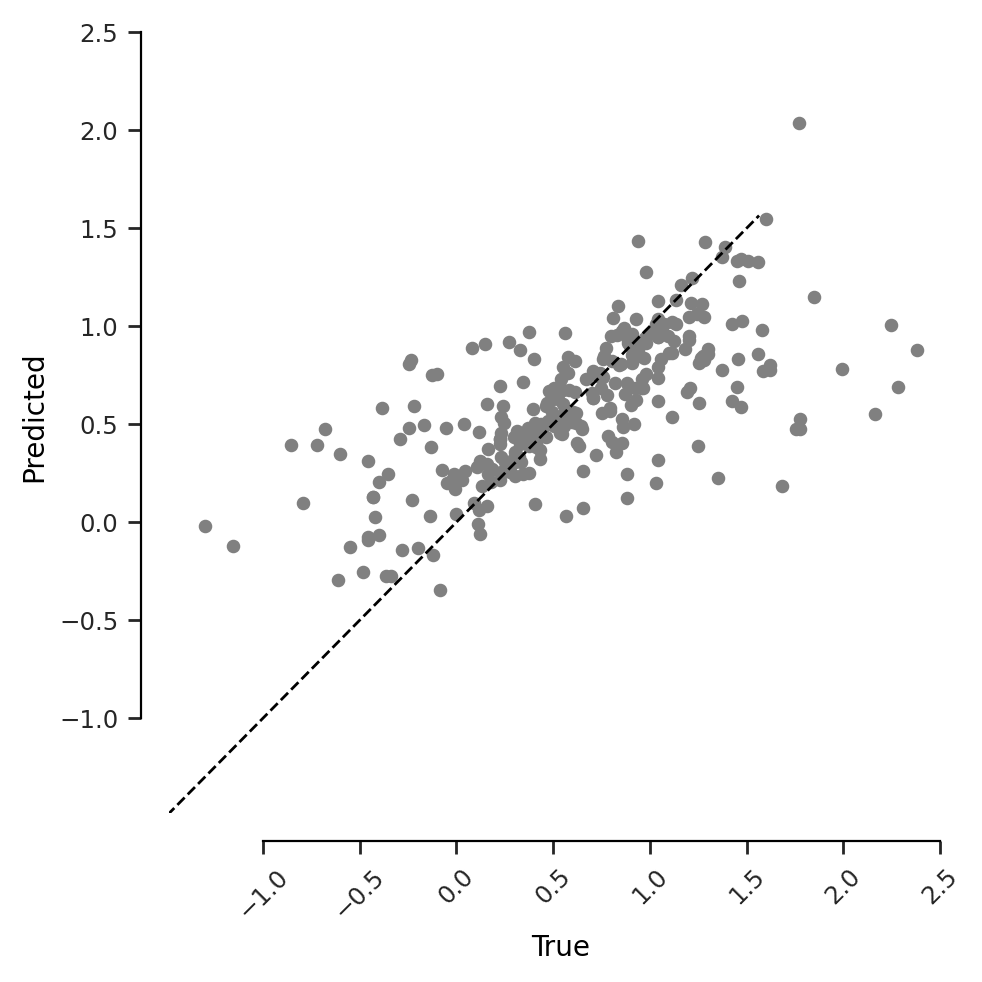

human_VDss_L_kg
(51,)
(51,)
2-fold :  47.05882352941176
3-fold :  66.66666666666666
5-fold :  82.35294117647058
gmfe :  2.5753105344611007
mfe :  1.374126081804714
bias :  -0.021118513870507782
rmse  0.5830686110569488
r2  0.33239975976000313


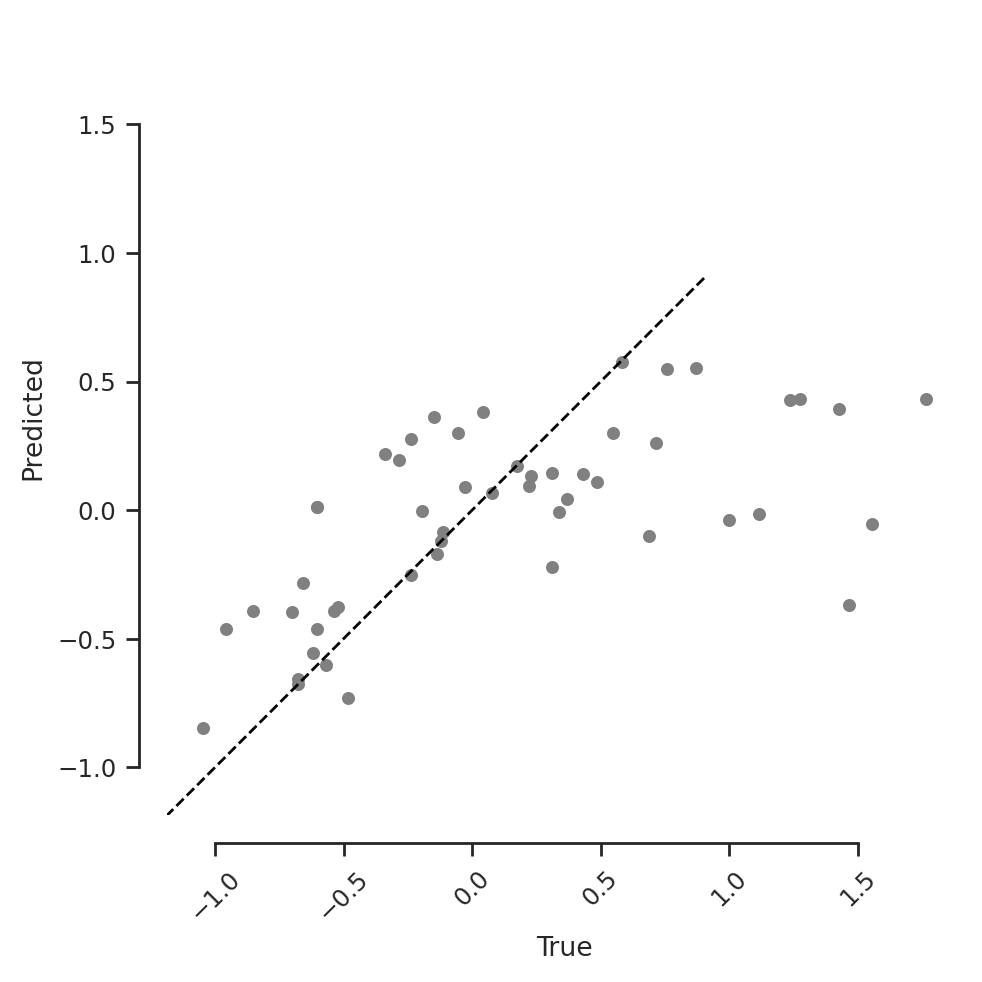

human_fup
(34,)
(34,)
2-fold :  23.52941176470588
3-fold :  47.05882352941176
5-fold :  55.88235294117647
gmfe :  4.3072991719497224
mfe :  1.819439318854104
bias :  0.06967861340279324
rmse  0.22537158624738013
r2  0.22721518007921448


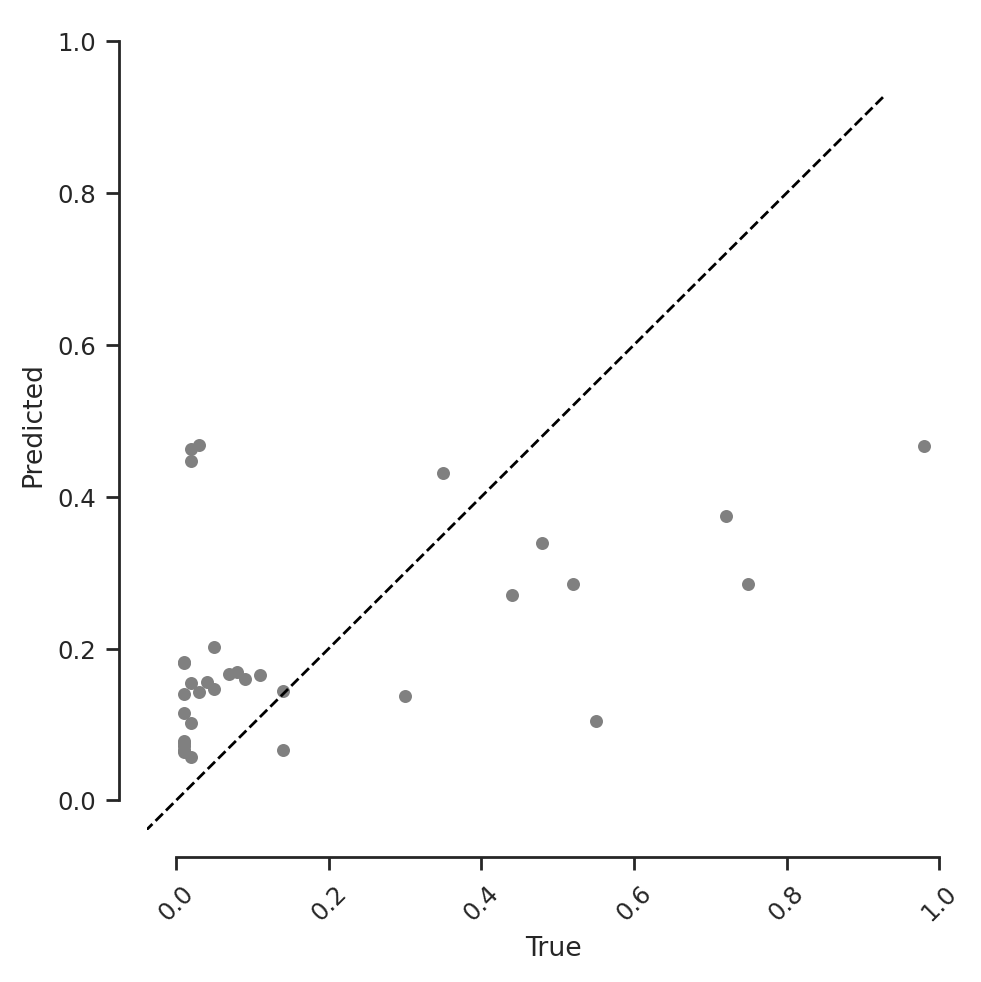

human_thalf
(38,)
(38,)
2-fold :  36.84210526315789
3-fold :  55.26315789473685
5-fold :  73.68421052631578
gmfe :  3.3091382641935634
mfe :  1.4790788430471074
bias :  -3.6594617366012288
rmse  0.6861441438985398
r2  0.05239514922346955


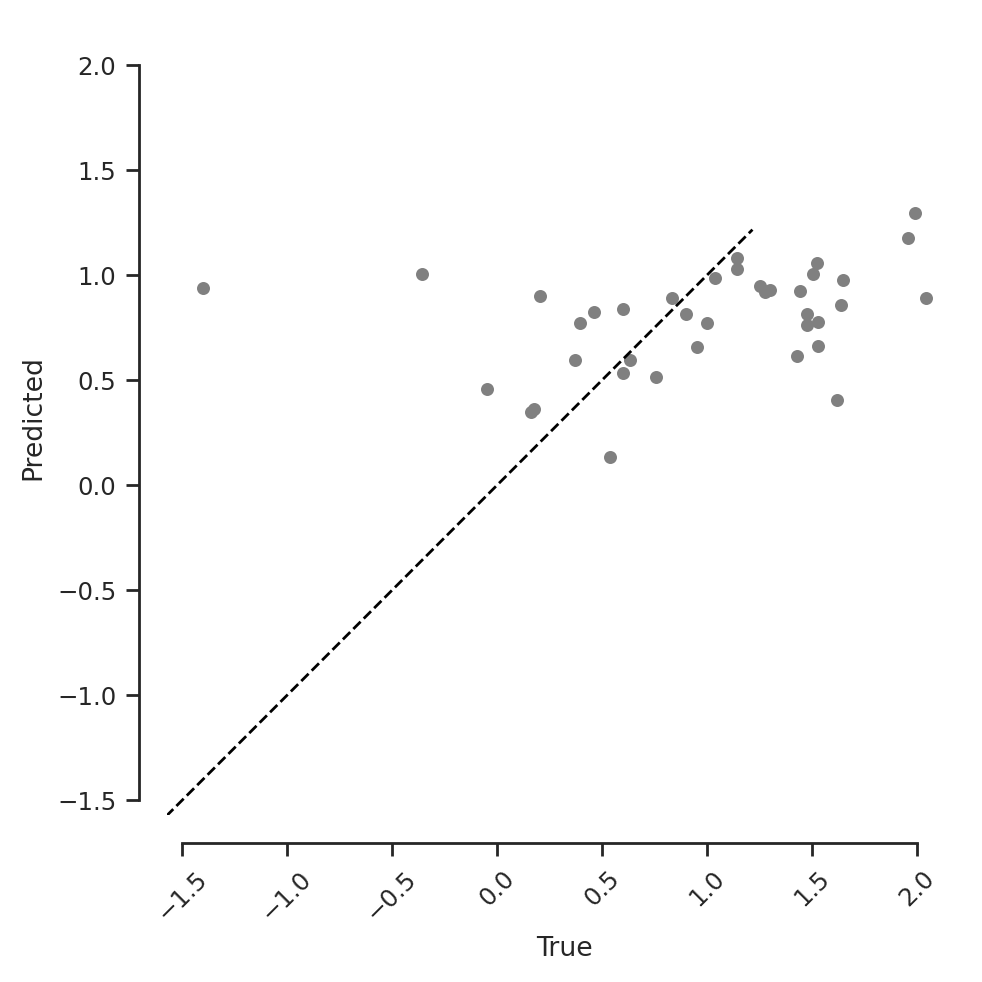

In [25]:
for endpoint in ["human_CL_mL_min_kg","human_VDss_L_kg","human_fup","human_thalf"]:
    
    print(endpoint)

    Y_test = df[[endpoint]].dropna().values.flatten()
    print(Y_test.shape)
    y_pred = preds[[endpoint]].iloc[df[[endpoint]].dropna().index].values.flatten()
    print(y_pred.shape)

    fold_2= count(y_pred, Y_test, 0.5, 2, endpoint)
    fold_3= count(y_pred, Y_test, 1/3, 3, endpoint)
    fold_5= count(y_pred, Y_test, 1/5, 5, endpoint)
    gmfe = calc_gmfe(y_pred, Y_test, endpoint)
    mfe = median_fold_change_error(y_pred, Y_test, endpoint)
    bias = calc_bias(y_pred, Y_test, endpoint)

    print("2-fold : ", fold_2)
    print("3-fold : ", fold_3)
    print("5-fold : ", fold_5)
    print("gmfe : ", gmfe)
    print("mfe : ", mfe)
    print("bias : ", bias)

    rmse = sqrt(mean_squared_error(Y_test, y_pred))
    print('rmse ',rmse)
    r2 = r2_score(Y_test, y_pred)
    print('r2 ',r2)

    
    fig = plt.figure(figsize =(5, 5), dpi=200) 

    plt.scatter(Y_test,  y_pred, color = 'gray', s=15) # s controls point size
    xleft, xright = plt.xlim()
    ybottom, ytop = plt.ylim()

    plt.xlim(min(xleft,ybottom) ,max(xright,ytop))
    plt.ylim(min(xleft,ybottom),max(xright,ytop))

    #add y=x line
    if (endpoint!="human_fup"):
        plt.plot([min(xleft,ybottom)-2,max(xright,ytop)-1],[min(xleft,ybottom)-2,max(xright,ytop)-1], lw=1, color='black', linestyle='dashed')

    else:
        plt.plot([min(xleft,ybottom)-0.2,max(xright,ytop)-0.1],[min(xleft,ybottom)-0.2,max(xright,ytop)-0.1], lw=1, color='black', linestyle='dashed')
    
    sns.set_context("paper", font_scale=1)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title("")

    sns.set_style('ticks')
    sns.despine(offset=10, trim=True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [26]:
##END HERE


#combine 4g and 4f


In [27]:
df

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,-0.431798,-0.602060,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,-0.236572,0.582063,0.01,1.442480
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,1.247237,1.555094,0.03,1.477121
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,1.158362,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,2.161368,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],1.556303,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.602060,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,1.472756,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,0.995635,NaN,NaN,NaN
